# Week 3 – Day 1 Assignment
# Artificial Neural Networks (ANN) — Object-Oriented Implementation



## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

RNG_SEED = 7
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)

print("NumPy:", np.__version__, "| TensorFlow:", tf.__version__)


I0000 00:00:1784612388.636302     543 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784612388.639112     543 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784612407.941313     543 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784612420.710795     543 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784612420.712750     543 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


NumPy: 2.4.4 | TensorFlow: 2.21.0


## 2. `Activations` — a small static-method library


In [2]:
class Activations:
    """Collection of activation functions and (where useful) their derivatives."""

    @staticmethod
    def binary_step(z):
        return np.where(z >= 0, 1, 0)

    @staticmethod
    def sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def sigmoid_derivative(z):
        s = Activations.sigmoid(z)
        return s * (1 - s)

    @staticmethod
    def tanh(z):
        return np.tanh(z)

    @staticmethod
    def relu(z):
        return np.maximum(0, z)

    @staticmethod
    def leaky_relu(z, alpha=0.1):
        return np.where(z > 0, z, alpha * z)

    @staticmethod
    def elu(z, alpha=1.0):
        return np.where(z > 0, z, alpha * (np.exp(z) - 1))

    @staticmethod
    def swish(z):
        """Bonus activation: x * sigmoid(x), used in EfficientNet-style models."""
        return z * Activations.sigmoid(z)

    @staticmethod
    def softmax(z):
        shifted = z - np.max(z)
        exp_z = np.exp(shifted)
        return exp_z / np.sum(exp_z)


# Quick demonstration
probe = np.array([-3.0, -1.0, 0.0, 1.0, 3.0])
for name in ["binary_step", "sigmoid", "tanh", "relu", "leaky_relu", "elu", "swish"]:
    fn = getattr(Activations, name)
    print(f"{name:12s}: {np.round(fn(probe), 3)}")
print(f"{'softmax':12s}: {np.round(Activations.softmax(probe), 3)} (sum={Activations.softmax(probe).sum():.3f})")


binary_step : [0 0 1 1 1]
sigmoid     : [0.047 0.269 0.5   0.731 0.953]
tanh        : [-0.995 -0.762  0.     0.762  0.995]
relu        : [0. 0. 0. 1. 3.]
leaky_relu  : [-0.3 -0.1  0.   1.   3. ]
elu         : [-0.95  -0.632  0.     1.     3.   ]
swish       : [-0.142 -0.269  0.     0.731  2.858]
softmax     : [0.002 0.015 0.041 0.112 0.829] (sum=1.000)


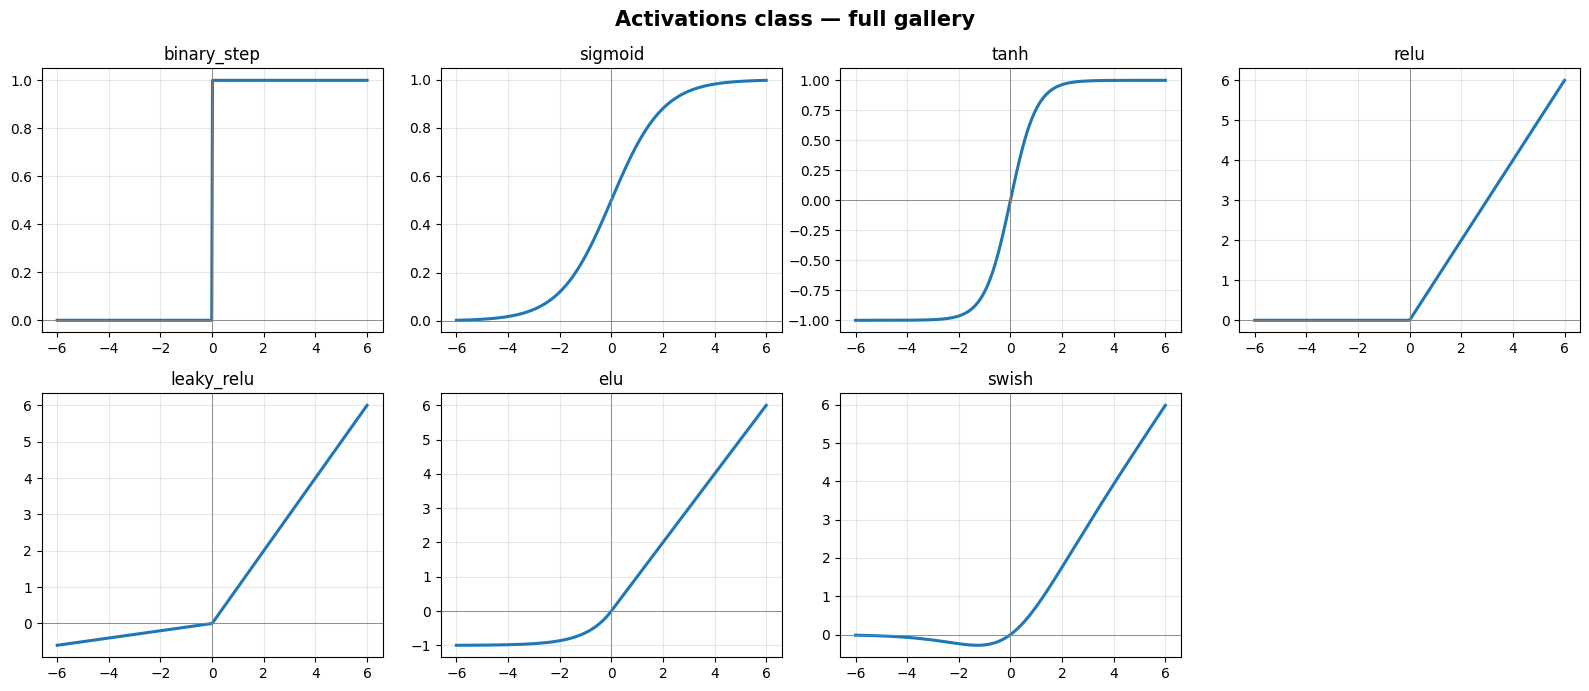

In [3]:
x = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
gallery = ["binary_step", "sigmoid", "tanh", "relu", "leaky_relu", "elu", "swish"]
for ax, name in zip(axes.flat, gallery):
    fn = getattr(Activations, name)
    ax.plot(x, fn(x), linewidth=2.2)
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.axvline(0, color="gray", linewidth=0.6)
    ax.set_title(name)
    ax.grid(alpha=0.3)
axes.flat[-1].axis("off")
plt.suptitle("Activations class — full gallery", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("v2_activation_gallery_output.png", dpi=150)
plt.show()


## 3. `Neuron` — a single computational unit



In [4]:
class Neuron:
    def __init__(self, n_inputs, activation="sigmoid", seed=None):
        rng = np.random.default_rng(seed)
        self.weights = rng.normal(0, 0.5, size=n_inputs)
        self.bias = 0.0
        self.activation_name = activation
        self.activation_fn = getattr(Activations, activation)

    def forward(self, x):
        z = np.dot(self.weights, x) + self.bias
        a = self.activation_fn(z)
        return z, a

    def __repr__(self):
        return f"Neuron(weights={np.round(self.weights,3)}, bias={self.bias:.3f}, activation={self.activation_name})"


neuron = Neuron(n_inputs=3, activation="sigmoid", seed=RNG_SEED)
x_sample = np.array([0.5, 0.8, -0.3])
neuron.weights = np.array([0.4, -0.2, 0.9])   # set explicit weights for a reproducible example
neuron.bias = 0.1

z, a = neuron.forward(x_sample)
print(neuron)
print(f"Input: {x_sample}")
print(f"z = {z:.4f}   a = f(z) = {a:.4f}")


Neuron(weights=[ 0.4 -0.2  0.9], bias=0.100, activation=sigmoid)
Input: [ 0.5  0.8 -0.3]
z = -0.1300   a = f(z) = 0.4675


## 4. `DenseNetwork` — a small feed-forward network class



In [5]:
class DenseLayer:
    def __init__(self, n_in, n_out, activation, seed=None):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.5, size=(n_out, n_in))
        self.b = np.zeros((n_out, 1))
        self.activation_fn = getattr(Activations, activation)
        self.activation_name = activation

    def forward(self, A_prev):
        Z = self.W @ A_prev + self.b
        A = self.activation_fn(Z)
        return Z, A


class DenseNetwork:
    def __init__(self, layer_sizes, activations, seed=None):
        assert len(layer_sizes) - 1 == len(activations), "Need one activation per layer transition"
        self.layers = []
        for i in range(len(layer_sizes) - 1):
            self.layers.append(DenseLayer(layer_sizes[i], layer_sizes[i + 1], activations[i], seed=seed))

    def predict(self, X, verbose=False):
        A = X
        for idx, layer in enumerate(self.layers, start=1):
            Z, A = layer.forward(A)
            if verbose:
                print(f"Layer {idx} ({layer.activation_name}) -> Z shape {Z.shape}")
                print("  Z:", np.round(Z.ravel(), 4))
                print("  A:", np.round(A.ravel(), 4))
        return A


net = DenseNetwork(layer_sizes=[2, 3, 1], activations=["tanh", "sigmoid"], seed=RNG_SEED)
X = np.array([[0.6], [0.9]])

prediction = net.predict(X, verbose=True)
print("\nFinal prediction:", np.round(prediction.ravel(), 4))


Layer 1 (tanh) -> Z shape (3, 1)
  Z: [ 0.1348 -0.483  -0.5826]
  A: [ 0.134  -0.4486 -0.5246]
Layer 2 (sigmoid) -> Z shape (1, 1)
  Z: [0.005]
  A: [0.5012]

Final prediction: [0.5012]


## 5. Cross-Check Against TensorFlow/Keras



In [6]:
keras_model = keras.Sequential([
    keras.Input(shape=(2,)),
    layers.Dense(3, activation="tanh", name="hidden"),
    layers.Dense(1, activation="sigmoid", name="output"),
])

W1, b1 = net.layers[0].W, net.layers[0].b
W2, b2 = net.layers[1].W, net.layers[1].b

keras_model.get_layer("hidden").set_weights([W1.T, b1.ravel()])
keras_model.get_layer("output").set_weights([W2.T, b2.ravel()])

keras_prediction = keras_model.predict(X.T, verbose=0)

print("DenseNetwork prediction :", np.round(prediction.ravel(), 6))
print("Keras prediction        :", np.round(keras_prediction.ravel(), 6))
print("Match:", np.allclose(prediction.ravel(), keras_prediction.ravel(), atol=1e-6))


E0000 00:00:1784612425.148301     543 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


DenseNetwork prediction : [0.501243]
Keras prediction        : [0.501243]
Match: True


## 6. Activation Gallery — Overlaid View

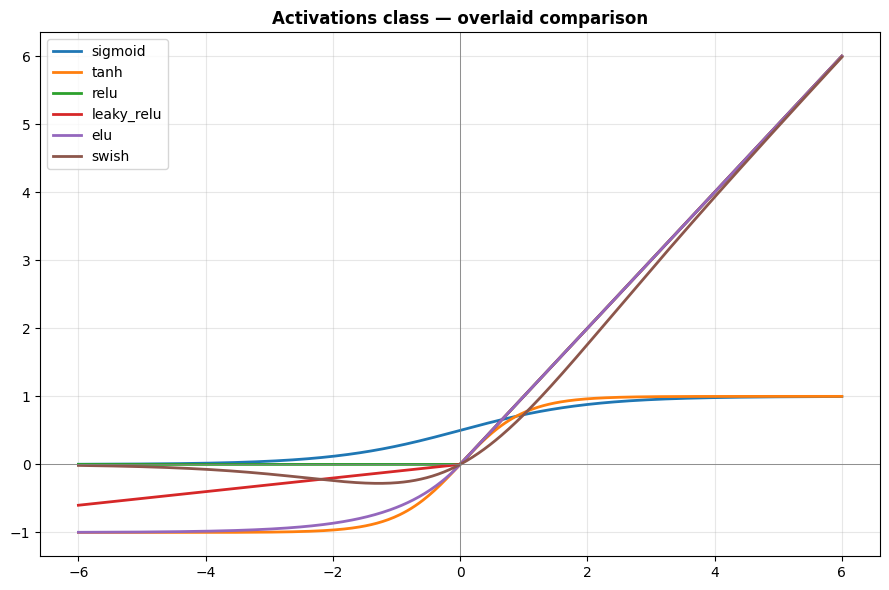

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
x = np.linspace(-6, 6, 400)
for name in ["sigmoid", "tanh", "relu", "leaky_relu", "elu", "swish"]:
    fn = getattr(Activations, name)
    ax.plot(x, fn(x), label=name, linewidth=2)
ax.axhline(0, color="gray", linewidth=0.6)
ax.axvline(0, color="gray", linewidth=0.6)
ax.legend()
ax.grid(alpha=0.3)
ax.set_title("Activations class — overlaid comparison", fontweight="bold")
plt.tight_layout()
plt.savefig("v2_activation_overlay_output.png", dpi=150)
plt.show()


## 7. Applied Project — Breast Cancer Wisconsin Classifier




In [8]:
dataset = load_breast_cancer()
X_all, y_all = dataset.data, dataset.target
print("Samples:", X_all.shape[0], "| Features:", X_all.shape[1], "| Classes:", dataset.target_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=RNG_SEED, stratify=y_all
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train/Test split:", X_train_s.shape, X_test_s.shape)


Samples: 569 | Features: 30 | Classes: ['malignant' 'benign']
Train/Test split: (426, 30) (143, 30)


In [9]:
def build_classifier(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(20, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

clf = build_classifier(X_train_s.shape[1])
history = clf.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    verbose=0,
)
print("Training finished.")


Training finished.


In [10]:
loss, acc = clf.evaluate(X_test_s, y_test, verbose=0)
print(f"Test accuracy: {acc:.4f}  |  Test loss: {loss:.4f}")


Test accuracy: 0.9790  |  Test loss: 0.0384


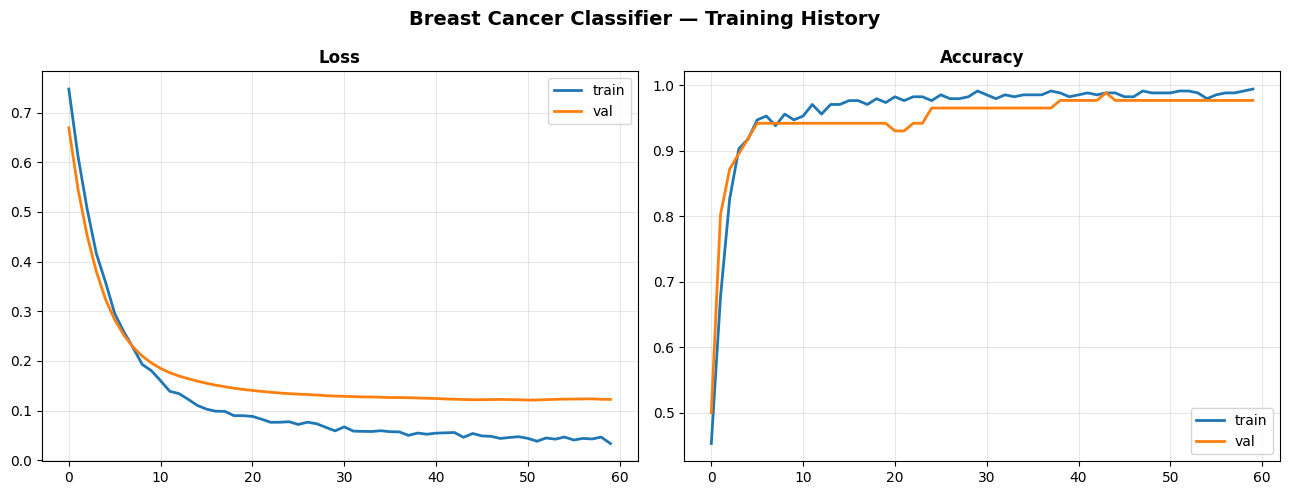

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history.history["loss"], label="train", linewidth=2)
axes[0].plot(history.history["val_loss"], label="val", linewidth=2)
axes[0].set_title("Loss", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="val", linewidth=2)
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Breast Cancer Classifier — Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("v2_training_curves_output.png", dpi=150)
plt.show()


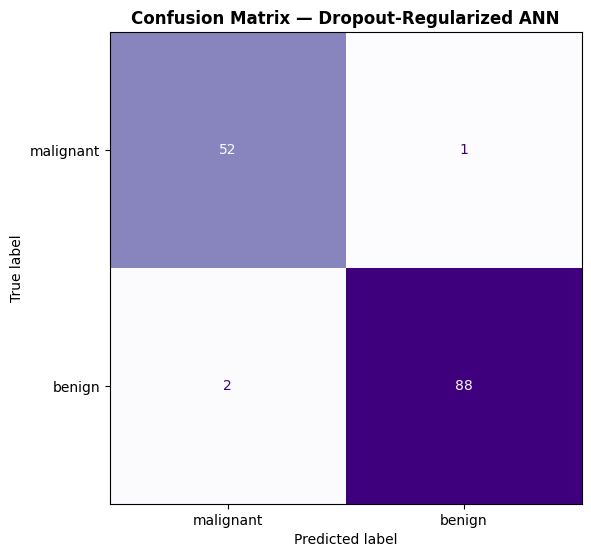

              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [12]:
y_prob = clf.predict(X_test_s, verbose=0)
y_pred = (y_prob.ravel() > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.target_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Confusion Matrix — Dropout-Regularized ANN", fontweight="bold")
plt.tight_layout()
plt.savefig("v2_confusion_matrix_output.png", dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=dataset.target_names))
